In [2]:
import pandas as pd
import numpy as np


## Load Dataset

In [3]:
JOB_DESC_PATH = '/Users/josepnat/Developer/AOL_NLP/data/raw/job_descriptions_bibek.csv'
RESUME_BHAWAL_PATH = '/Users/josepnat/Developer/AOL_NLP/data/raw/resumes_bhawal/Resume.csv'
RESUME_EJAZ_PATH = '/Users/josepnat/Developer/AOL_NLP/data/raw/resumes_ejaz.csv'

df_jobs = pd.read_csv(JOB_DESC_PATH)
df_resume_bhawal = pd.read_csv(RESUME_BHAWAL_PATH)
df_resume_ejaz = pd.read_csv(RESUME_EJAZ_PATH)

print(f"Total Job Descriptions : {df_jobs.shape[0]} baris")
print(f"Total Resume (Bhawal)  : {df_resume_bhawal.shape[0]} baris")
print(f"Total Resume (Ejaz)    : {df_resume_ejaz.shape[0]} baris")

Total Job Descriptions : 10000 baris
Total Resume (Bhawal)  : 2484 baris
Total Resume (Ejaz)    : 962 baris


In [4]:
display(df_resume_ejaz.head(3))

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."


In [5]:
display(df_resume_bhawal.head(3))

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR


## Membersihkan dan menggabungkan dataset Resume

In [6]:
df_bhawal_clean = df_resume_bhawal[['Category', 'Resume_str']].copy()
df_bhawal_clean.rename(columns={'Resume_str':'Resume'}, inplace=True)

# Gabungkan 2 data Ejaz dan Bhawal yang sudah bersih
df_resume_merged = pd.concat([df_resume_ejaz, df_bhawal_clean], ignore_index=True) 

# Hapus baris yang kosong
df_resume_merged.dropna(inplace=True)
df_resume_merged.drop_duplicates(inplace=True)

print(f"Total baris setelah digabung dan dibersihkan: {df_resume_merged.shape[0]} baris")
display(df_resume_merged.head())

Total baris setelah digabung dan dibersihkan: 2648 baris


,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


## EDA

#### Melihat distribusi kategori resume

/var/folders/1q/8jq91msj3j757kq0m0p6h24r0000gn/T/ipykernel_1138/285335849.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=kategori_counts.index, x=kategori_counts.values, palette='viridis')


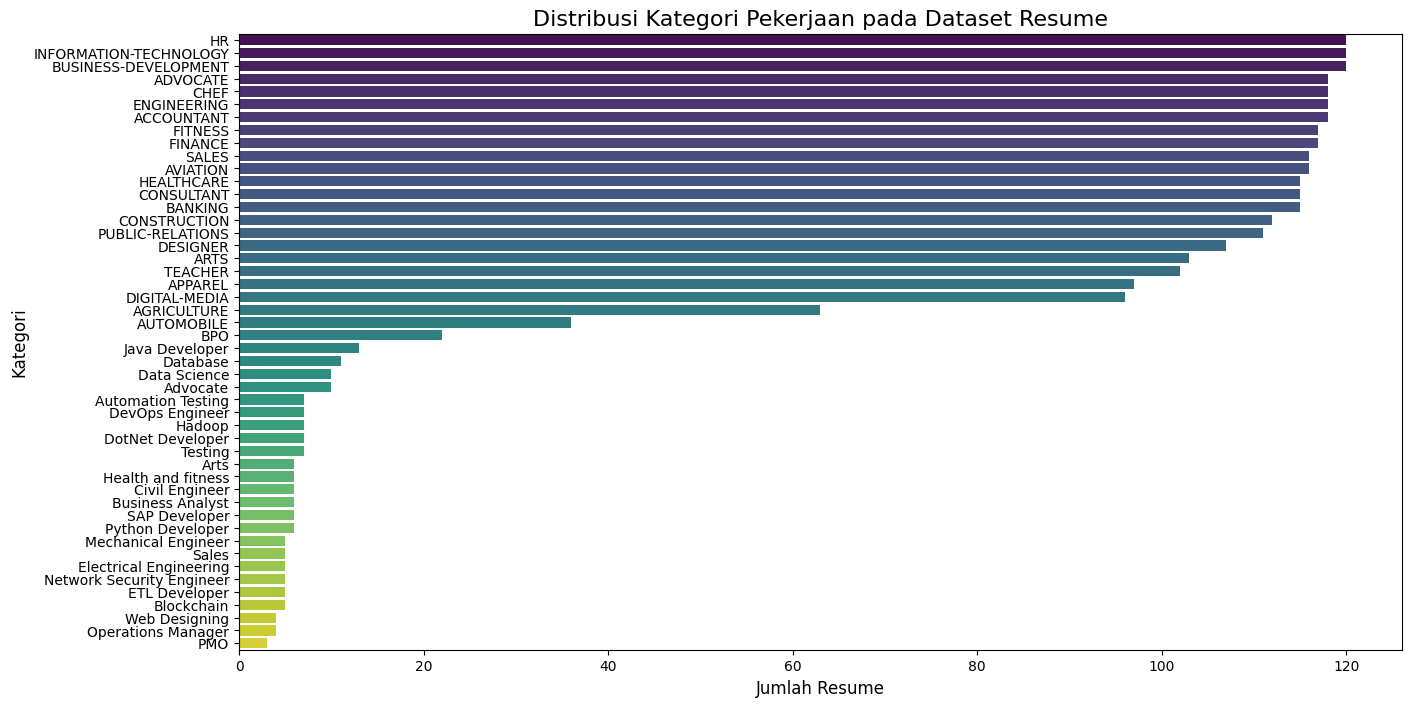

Total Kategori Unik: 48


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
kategori_counts = df_resume_merged['Category'].value_counts()

# Bar chart
sns.barplot(y=kategori_counts.index, x=kategori_counts.values, palette='viridis')
plt.title('Distribusi Kategori Pekerjaan pada Dataset Resume', fontsize=16)
plt.xlabel('Jumlah Resume', fontsize=12)
plt.ylabel('Kategori', fontsize=12)
plt.show()

print(f"Total Kategori Unik: {df_resume_merged['Category'].nunique()}")


Statistik panjang kata dari resume


count    2648.000000
mean      787.202795
std       383.302222
min         0.000000
25%       635.000000
50%       745.000000
75%       921.000000
max      5190.000000
Name: Word_Count, dtype: float64

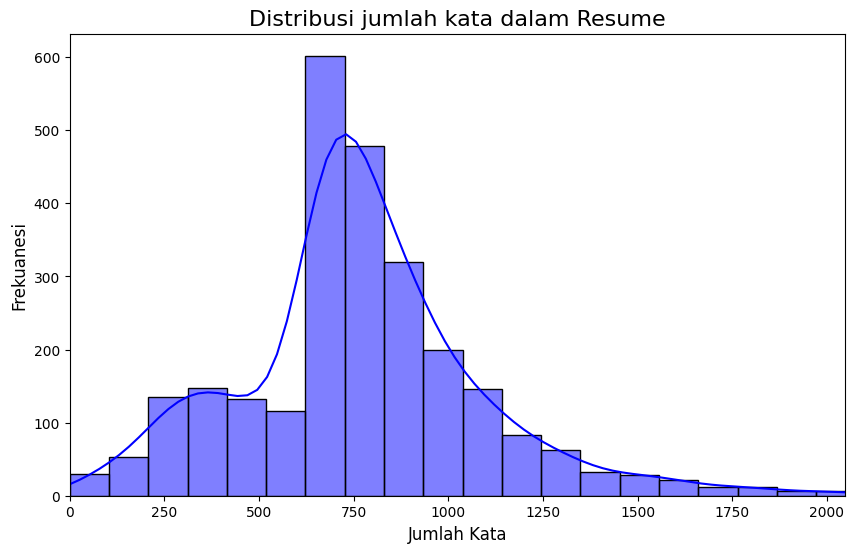

In [8]:
# Menganalisis Panjang Teks Resume (Word Count)
df_resume_merged['Word_Count'] = df_resume_merged['Resume'].apply(lambda x: len(str(x).split()))

print("Statistik panjang kata dari resume")
display(df_resume_merged['Word_Count'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df_resume_merged['Word_Count'], bins=50, kde=True, color='blue')
plt.title("Distribusi jumlah kata dalam Resume", fontsize =16)
plt.xlabel("Jumlah Kata", fontsize = 12)
plt.ylabel("Frekuanesi", fontsize= 12)
# Batasi sumbu X
plt.xlim(0, df_resume_merged['Word_Count'].quantile(0.99))
plt.show()

In [9]:
# Ngintip 1 contoh teks mentah secara acak
import random

random_idx = random.randint(0, len(df_resume_merged) - 1)
sample_category = df_resume_merged.iloc[random_idx]['Category']
sample_text = df_resume_merged.iloc[random_idx]['Resume']

print(f"=== KATEGORI: {sample_category.upper()} ===")
print(f"Panjang Karakter: {len(sample_text)}")
print("-" * 50)
print(sample_text[:1000]) # Cuma nge-print 1000 karakter pertama biar ga kepanjangan

=== KATEGORI: AGRICULTURE ===
Panjang Karakter: 5481
--------------------------------------------------
         QUALITY ASSURANCE ASSOCIATE       Summary     Enthusiastic Chemist eager to pursue a lasting career in the Agriculture industry.  Detail-oriented Chemist with expertise in the instrumentation, physical and wet chemistry, and formulation as well as coordinating testing and development.       Highlights          HPLC  GC  FTIR       UV-Vis  Physical Chemistry techniques  GMP/GCP              Accomplishments     Led the pre-formulation and formulation development of a topical cream and gel for psoriases which successfully entered clinical trials.       Experience     01/2011   to   Current     Quality Assurance Associate    Company Name   －   City  ,   State      Preparation, configuration, execution and authoring of reports for IQ, OQ and PQ protocols for Labware LIMS and Trackwise Systems  Managed quality systems change control, site training, deviation and CAPA compliance pr

### EDA untuk Job Desxriptions

Info Dataset Job Description:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   id                    10000 non-null  int64
 1   title                 10000 non-null  str  
 2   department            10000 non-null  str  
 3   location              10000 non-null  str  
 4   required_skills       10000 non-null  str  
 5   preferred_skills      10000 non-null  str  
 6   education             10000 non-null  str  
 7   experience_required   10000 non-null  int64
 8   responsibilities      10000 non-null  str  
 9   employment_type       10000 non-null  str  
 10  company_name          10000 non-null  str  
 11  industry              10000 non-null  str  
 12  salary_range          10000 non-null  str  
 13  job_posted_date       10000 non-null  str  
 14  application_deadline  10000 non-null  str  
 15  work_mode             10000 non-nul

None


Distribusi mode kerja (Work Mode):


work_mode
Hybrid    3421
Onsite    3292
WFH       3287
Name: count, dtype: int64

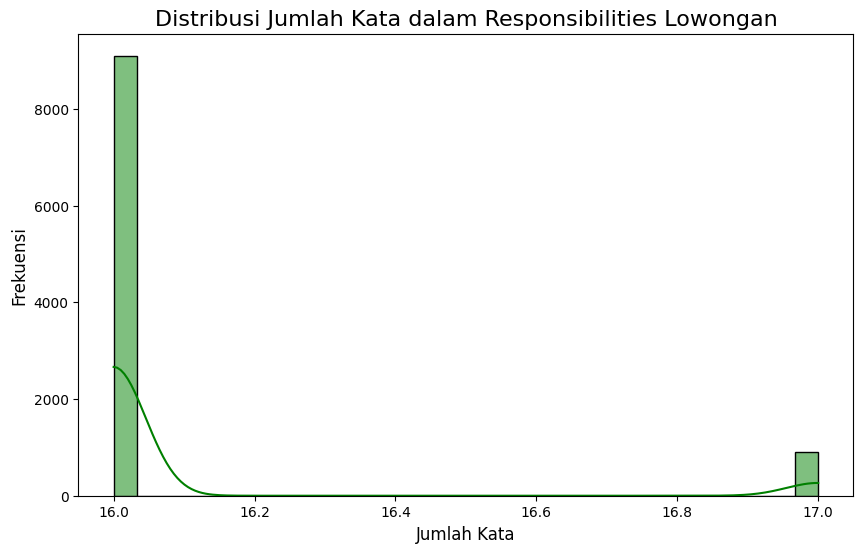

In [10]:
print("Info Dataset Job Description:")
display(df_jobs.info())

print("\nDistribusi mode kerja (Work Mode):")
display(df_jobs['work_mode'].value_counts())

# Menghitung panjang kata untuk Job Description
df_jobs['Word_Count'] = df_jobs['responsibilities'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(df_jobs['Word_Count'], bins=30, kde=True, color='green')
plt.title('Distribusi Jumlah Kata dalam Responsibilities Lowongan', fontsize=16)
plt.xlabel('Jumlah Kata', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.show()

## Text Preprocessing

In [11]:
import re
def clean_resume_text(text):
    # Inputnya harus string
    text = str(text)

    # Lowercase
    text = text.lower()

    # Hapus URL/Link (kalau ada pelamar yang masukin link portofolio)
    text = re.sub('https\S+\s', ' ', text)

    # Hapus email karena g relevan
    text = re.sub('\S+@\S+', ' ', text)

    # Hapus tanda baca
    text = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', text)

    # Hapus angka 
    text = re.sub(r'\d+', ' ', text)

    # Hapus spasi berlebih
    text = re.sub('\s+', ' ', text)

    # Hapus spasi di awal dan akhir kalimat
    text = text.strip()

    return text

print("=== SEBELUM DIBERSIHKAN ===")
print(sample_text[:500])

print("\n=== SESUDAH DIBERSIHKAN ===")
cleaned_sample = clean_resume_text(sample_text)
print(cleaned_sample[:500])

=== SEBELUM DIBERSIHKAN ===
         QUALITY ASSURANCE ASSOCIATE       Summary     Enthusiastic Chemist eager to pursue a lasting career in the Agriculture industry.  Detail-oriented Chemist with expertise in the instrumentation, physical and wet chemistry, and formulation as well as coordinating testing and development.       Highlights          HPLC  GC  FTIR       UV-Vis  Physical Chemistry techniques  GMP/GCP              Accomplishments     Led the pre-formulation and formulation development of a topical cream and gel

=== SESUDAH DIBERSIHKAN ===
quality assurance associate summary enthusiastic chemist eager to pursue a lasting career in the agriculture industry detail oriented chemist with expertise in the instrumentation physical and wet chemistry and formulation as well as coordinating testing and development highlights hplc gc ftir uv vis physical chemistry techniques gmp gcp accomplishments led the pre formulation and formulation development of a topical cream and gel for pso

<>:10: SyntaxWarning: invalid escape sequence '\S'
<>:13: SyntaxWarning: invalid escape sequence '\S'
<>:16: SyntaxWarning: invalid escape sequence '\]'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\S'
<>:13: SyntaxWarning: invalid escape sequence '\S'
<>:16: SyntaxWarning: invalid escape sequence '\]'
<>:22: SyntaxWarning: invalid escape sequence '\s'
/var/folders/1q/8jq91msj3j757kq0m0p6h24r0000gn/T/ipykernel_1138/3976012191.py:10: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub('https\S+\s', ' ', text)
/var/folders/1q/8jq91msj3j757kq0m0p6h24r0000gn/T/ipykernel_1138/3976012191.py:13: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub('\S+@\S+', ' ', text)
/var/folders/1q/8jq91msj3j757kq0m0p6h24r0000gn/T/ipykernel_1138/3976012191.py:16: SyntaxWarning: invalid escape sequence '\]'
  text = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', text)
/var/folders/1q/8jq91msj3j757kq0m0p6h24r0000gn/T

In [12]:
# Mengaplikasikan fungsi pembersih ke seluruh dataset

print("Membersihkan dataset Resume .....")
# Bikin kolom baru (Resume_Cleaned) agar datanya ttep aman
df_resume_merged['Resume_Cleaned'] = df_resume_merged['Resume'].apply(clean_resume_text)

print("Membersihkan dataset Job Descriptions .....")
# Bersihkan juga kolom responsibilities dan required_skills di data lowongan
df_jobs['Responsibilities_Cleaned'] = df_jobs['responsibilities'].apply(clean_resume_text)
df_jobs['Skills_Cleaned'] = df_jobs['required_skills'].apply(clean_resume_text)

print("Berezzz, berikut hasilnya:")
# Bandingin teks kotor ama bersih
display(df_resume_merged[['Category', 'Resume', 'Resume_Cleaned']].head())


Membersihkan dataset Resume .....
Membersihkan dataset Job Descriptions .....
Berezzz, berikut hasilnya:


,Category,Resume,Resume_Cleaned
0,Data Science,Skills * Programming Languages: Python (pandas...,skills programming languages python pandas num...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,education details may to may b e uit rgpv data...
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",areas of interest deep learning control system...
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,skills â¢ r â¢ python â¢ sap hana â¢ table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",education details mca ymcaust faridabad haryan...


## Preprocessing tahap 2

In [13]:
# Hapus Mojibake (Karakter aneh) & Stopwords
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_resume_text_v2(text):
    text = str(text)
    text = text.lower()
    
    # Hapus URL dan Email
    text = re.sub('http\S+\s*', ' ', text)
    text = re.sub('\S+@\S+', ' ', text)
    
    # NEW: Hapus karakter Non-ASCII (Ini yang membasmi â€¢ dan simbol alien lainnya!)
    text = re.sub(r'[^\x00-\x7f]', r' ', text)
    
    # Hapus tanda baca dan angka
    text = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', text)
    text = re.sub(r'\d+', ' ', text)
    
    # Hapus Stopwords ("and", "the", "to", dll)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    text = ' '.join(words)
    
    # Hapus spasi berlebih
    text = re.sub('\s+', ' ', text)
    text = text.strip()
    
    return text

print("Mulai pembersihan Tahap 2 (membasmi alien dan stopwords)...")
df_resume_merged['Resume_Cleaned_v2'] = df_resume_merged['Resume'].apply(clean_resume_text_v2)

display(df_resume_merged[['Category', 'Resume_Cleaned', 'Resume_Cleaned_v2']].head())

<>:13: SyntaxWarning: invalid escape sequence '\S'
<>:14: SyntaxWarning: invalid escape sequence '\S'
<>:20: SyntaxWarning: invalid escape sequence '\]'
<>:29: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\S'
<>:14: SyntaxWarning: invalid escape sequence '\S'
<>:20: SyntaxWarning: invalid escape sequence '\]'
<>:29: SyntaxWarning: invalid escape sequence '\s'
/var/folders/1q/8jq91msj3j757kq0m0p6h24r0000gn/T/ipykernel_1138/3721266330.py:13: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub('http\S+\s*', ' ', text)
/var/folders/1q/8jq91msj3j757kq0m0p6h24r0000gn/T/ipykernel_1138/3721266330.py:14: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub('\S+@\S+', ' ', text)
/var/folders/1q/8jq91msj3j757kq0m0p6h24r0000gn/T/ipykernel_1138/3721266330.py:20: SyntaxWarning: invalid escape sequence '\]'
  text = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', text)
/var/folders/1q/8jq91msj3j757kq0m0p6h24r0000gn/T

Mulai pembersihan Tahap 2 (membasmi alien dan stopwords)...


,Category,Resume_Cleaned,Resume_Cleaned_v2
0,Data Science,skills programming languages python pandas num...,skills programming languages python pandas num...
1,Data Science,education details may to may b e uit rgpv data...,education details may may b e uit rgpv data sc...
2,Data Science,areas of interest deep learning control system...,areas interest deep learning control system de...
3,Data Science,skills â¢ r â¢ python â¢ sap hana â¢ table...,skills r python sap hana tableau sap hana sql ...
4,Data Science,education details mca ymcaust faridabad haryan...,education details mca ymcaust faridabad haryan...


## Lemmatization

In [14]:
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(lemmatized_words)

print("Mulai proses Lemmatization (mohon tunggu sebentar)...")
# Kita timpa aja ke kolom v2 agar tidak terlalu banyak kolom
df_resume_merged['Resume_Cleaned_v2'] = df_resume_merged['Resume_Cleaned_v2'].apply(lemmatize_text)

print("BEREZZZZ! Intip hasilnya:")
display(df_resume_merged[['Category', 'Resume_Cleaned', 'Resume_Cleaned_v2']].head())

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/josepnat/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/josepnat/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Mulai proses Lemmatization (mohon tunggu sebentar)...
BEREZZZZ! Intip hasilnya:


,Category,Resume_Cleaned,Resume_Cleaned_v2
0,Data Science,skills programming languages python pandas num...,skill programming language python panda numpy ...
1,Data Science,education details may to may b e uit rgpv data...,education detail may may b e uit rgpv data sci...
2,Data Science,areas of interest deep learning control system...,area interest deep learning control system des...
3,Data Science,skills â¢ r â¢ python â¢ sap hana â¢ table...,skill r python sap hana tableau sap hana sql s...
4,Data Science,education details mca ymcaust faridabad haryan...,education detail mca ymcaust faridabad haryana...


## EDA part 2

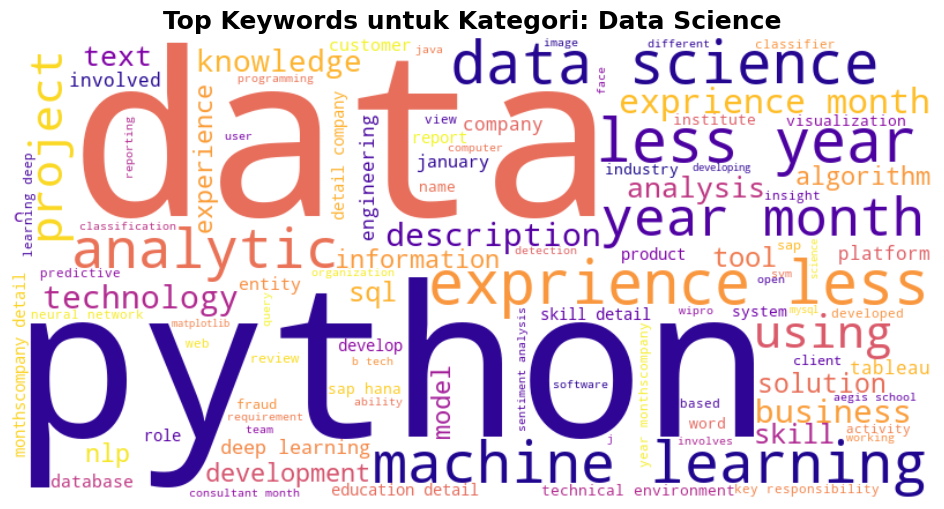

In [15]:
from wordcloud import WordCloud

kategori_pilihan = 'Data Science'

# Gabungkan semua teks resume di kategori tersebut menjadi satu teks panjang
text_kategori = " ".join(df_resume_merged[df_resume_merged['Category'] == kategori_pilihan]['Resume_Cleaned_v2'].dropna())

wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    colormap='plasma', 
    max_words=100
).generate(text_kategori)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title(f'Top Keywords untuk Kategori: {kategori_pilihan}', fontsize=18, fontweight='bold')
plt.show()

## Feature Extraction (Text Vectorization)

In [16]:
# Menggunakan TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
import random

# Kita batasi maksimal 5000 kata terpenting agar memori laptop ga sesek napas
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Ubah teks resume jadi matrix angka
resume_matrix = tfidf_vectorizer.fit_transform(df_resume_merged['Resume_Cleaned_v2'])

print(f"Ukuran Matriks Resume: {resume_matrix.shape}")
print(f"Jumlah Pelamar (Baris) : {resume_matrix.shape[0]}")
print(f"Jumlah Kosakata (Kolom): {resume_matrix.shape[1]}")

# Cek kosakata apa saja yang berhasil ditangkap oleh mesin
fitur_kata = tfidf_vectorizer.get_feature_names_out()
print("\nContoh 20 kosakata (fitur) yang dimengerti mesin:")
print(random.sample(list(fitur_kata), 20))

Ukuran Matriks Resume: (2648, 5000)
Jumlah Pelamar (Baris) : 2648
Jumlah Kosakata (Kolom): 5000

Contoh 20 kosakata (fitur) yang dimengerti mesin:
['capturing', 'org', 'sure', 'gold', 'passenger', 'recipient', 'worker', 'together', 'revenue', 'bw', 'barrier', 'organization', 'pleasant', 'commercial', 'removed', 'nebraska', 'behavioral', 'mathematics', 'instructional', 'pump']


## Cosine Similarity ibarat Matchmaker

In [17]:
from sklearn.metrics.pairwise import cosine_similarity

print("1. Menggabungkan Skills dan Responsibilities dari Job Description...")
df_jobs['Job_Text_Cleaned'] = df_jobs['Skills_Cleaned'] + " " + df_jobs['Responsibilities_Cleaned']
# Lemmatize job description
df_jobs['Job_Text_Cleaned'] = df_jobs['Job_Text_Cleaned'].apply(lemmatize_text)

print("2. Mengubah Job Description menjadi Angka...")
job_matrix = tfidf_vectorizer.transform(df_jobs['Job_Text_Cleaned'])

# Tes
job_index_test = 0
job_title_test = df_jobs.iloc[job_index_test]['title']
print(f"\n--- MENCARI KANDIDAT TERBAIK UNTUK LOWONGAN: {job_title_test.upper()} ---")

similarity_scores = cosine_similarity(job_matrix[job_index_test], resume_matrix)

top_5_indices = similarity_scores[0].argsort()[-5:][::-1]

print("\n=== TOP 5 KANDIDAT TERBAIK ===")
for rank, idx in enumerate(top_5_indices):
    score = similarity_scores[0][idx]
    kategori = df_resume_merged.iloc[idx]['Category']
    print(f"Rank {rank+1} | Kategori Resume Asli: {kategori} | Skor Kecocokan: {score:.4f}")

1. Menggabungkan Skills dan Responsibilities dari Job Description...
2. Mengubah Job Description menjadi Angka...

--- MENCARI KANDIDAT TERBAIK UNTUK LOWONGAN: SOFTWARE ENGINEER ---

=== TOP 5 KANDIDAT TERBAIK ===
Rank 1 | Kategori Resume Asli: ARTS | Skor Kecocokan: 0.1955
Rank 2 | Kategori Resume Asli: ADVOCATE | Skor Kecocokan: 0.1650
Rank 3 | Kategori Resume Asli: ENGINEERING | Skor Kecocokan: 0.1575
Rank 4 | Kategori Resume Asli: ENGINEERING | Skor Kecocokan: 0.1570
Rank 5 | Kategori Resume Asli: Python Developer | Skor Kecocokan: 0.1535


In [18]:
# Cell 17: cek alasan Hasil Rekomendasi (Kenapa bisa nyasar?)

# 1. Tampilkan isi Job Description yang dicari
print("=== TEKS LOWONGAN (SOFTWARE ENGINEER) ===")
print(df_jobs.iloc[job_index_test]['Job_Text_Cleaned'])
print("-" * 50)

# 2. Tampilkan isi Resume Rank 1 (Anak ARTS)
juara_1_index = top_5_indices[0]
print("\n=== TEKS RESUME RANK 1 (ARTS) ===")
# Print 1000 karakter pertama biar ga kepanjangan
print(df_resume_merged.iloc[juara_1_index]['Resume_Cleaned_v2'][:1000])

=== TEKS LOWONGAN (SOFTWARE ENGINEER) ===
django firebase microservices react rest apis scala tdd work on software engineer task collaborate with team maintain code quality and deliver feature on time
--------------------------------------------------

=== TEKS RESUME RANK 1 (ARTS) ===
software engineer profile experienced software engineer generalist strong interest game play ai programming professional experience software engineer current company name city state star war galaxy hero io android fall worked product manager implement game telemetry implemented various feature fixed bug required soft launch unannounced mobile strategy title io android unreleased established first playable prototype unity player controlled unit utilized navigation mesh obeying rotational movement constraint created custom code drive vehicle tread animation based vehicle velocity unannounced mobile role playing title io android unreleased worked artist develop player animation movement code using unity d l

## Tes model

In [19]:
import sys
import os
# pindah ke root directory (AOL_NLP)
sys.path.append(os.path.abspath(os.path.join('..')))

# Di Notebook
from src.models.recommender import ResumeRecommender

# Inisialisasi
engine = ResumeRecommender()
engine.fit(df_resume_merged)

# Tes rekomendasi
test_job = "looking for a developer with python and django skills"
results = engine.get_recommendations(test_job)

for r in results:
    print(f"Score: {r['score']:.4f} | Cat: {r['category']}")

Model berhasil dilatih dengan 2648 resume.
Score: 0.4892 | Cat: Python Developer
Score: 0.4719 | Cat: Python Developer
Score: 0.4430 | Cat: Python Developer
Score: 0.3829 | Cat: Python Developer
Score: 0.3174 | Cat: Python Developer


In [20]:
engine.save_model()

Model berhasil disimpan ke folder models/


In [21]:
# Cell 18: Mengubah PDF menjadi Teks
import PyPDF2

def extract_text_from_pdf(pdf_path):
    text = ""
    try:
        with open(pdf_path, 'rb') as file:
            reader = PyPDF2.PdfReader(file)
            # Looping untuk membaca semua halaman PDF
            for page in reader.pages:
                text += page.extract_text() + " "
        return text
    except Exception as e:
        return f"Error reading PDF: {e}"

# Tentukan path file CV kamu
cv_pdf_path = '/Users/josepnat/Developer/AOL_NLP/data/raw/CV_ATS_JOSEP_NATANAEL_PASARIBU .pdf' # Ganti nama file-nya jika berbeda

print("Mengekstrak teks dari PDF...")
cv_text_raw = extract_text_from_pdf(cv_pdf_path)

# Tampilkan 500 karakter pertama untuk memastikan berhasil dibaca
print("\n=== HASIL EKSTRAKSI PDF ===")
print(cv_text_raw[:500])

Mengekstrak teks dari PDF...

=== HASIL EKSTRAKSI PDF ===
A dedicated Computer Science student at BINUS University specializing in Artificial Intelligence and
Full-stack Development. Proven track record of developing functional Deep Learning models for
image classification and designing efficient relational database systems. A natural leader with
demonstrated abilities in mentoring freshmen, organizing charity events, and conducting technical
workshops in English.
Selected to mentor incoming students during the inauguration period and throughout their 


In [22]:
# Skill Extractor & Gap Analyzer
import spacy
from spacy.matcher import PhraseMatcher

print("Memuat model NLP spaCy...")
nlp = spacy.load("en_core_web_md")

# 1. Membangun "Kamus Skill" (Nantinya bisa diperluas dengan dataset Ejaz)
DAFTAR_SKILL_IT = [
    "python", "java", "c++", "react", "django", "flutter", "dart", 
    "artificial intelligence", "machine learning", "deep learning", "nlp", 
    "computer vision", "image classification", "full-stack development",
    "rest api", "sql", "mysql", "database", "firebase", "tensorflow", "keras",
    "data analysis", "agile", "scrum", "git", "github", "docker", "cloud"
]

# Membuat matcher spaCy untuk mendeteksi skill di dalam kalimat
matcher = PhraseMatcher(nlp.vocab, attr="LOWER")
patterns = [nlp.make_doc(text) for text in DAFTAR_SKILL_IT]
matcher.add("SKILL_LIST", patterns)

def extract_skills(text):
    """Fungsi mengekstrak skill dari teks"""
    doc = nlp(text)
    matches = matcher(doc)
    
    skills_found = set()
    for match_id, start, end in matches:
        span = doc[start:end]
        skills_found.add(span.text.lower())
        
    return skills_found

def analyze_skill_gap(cv_text, job_desc_text):
    """Fungsi membandingkan CV vs Job Description"""
    print("Menganalisis dokumen...")
    
    # 1. Ekstrak skill
    cv_skills = extract_skills(cv_text)
    jd_skills = extract_skills(job_desc_text)
    
    # 2. Operasi Himpunan (Set Operations) untuk Gap Analysis
    matched_skills = jd_skills.intersection(cv_skills)
    missing_skills = jd_skills.difference(cv_skills)
    extra_skills = cv_skills.difference(jd_skills)
    
    # 3. Hitung Persentase
    if len(jd_skills) > 0:
        match_percentage = (len(matched_skills) / len(jd_skills)) * 100
    else:
        match_percentage = 0.0
        
    return {
        "score": match_percentage,
        "matched": matched_skills,
        "missing": missing_skills,
        "extra": extra_skills,
        "jd_skills": jd_skills
    }

# Test


# Lowongan kerja incaran (Kombinasi AI & Backend)
contoh_lowongan = """
We are looking for an AI & Full-Stack Engineer. The ideal candidate must have strong
knowledge in Artificial Intelligence and Deep Learning for computer vision tasks. 
Experience with Full-stack development, managing Database systems, and containerization 
using Docker is required. Familiarity with React and Python is a huge plus.
"""

# Jalankan analisis membandingkan CV-mu dengan Lowongan di atas
hasil_analisis = analyze_skill_gap(cv_text_raw, contoh_lowongan)

print(f"\n=== HASIL ANALISIS SMART CV ===")
print(f"Kecocokan Skill: {hasil_analisis['score']:.2f}%\n")

print(f"MATCHED SKILLS (Sudah ada di CV-mu):")
for s in hasil_analisis['matched']: print(f"   - {s.title()}")

print(f"\nMISSING SKILLS (Skill Gap - Perlu dipelajari/ditambahkan):")
for s in hasil_analisis['missing']: print(f"   - {s.title()}")

print(f"\nEXTRA SKILLS (Skill di CV-mu yang jadi nilai plus):")
for s in list(hasil_analisis['extra'])[:5]: print(f"   - {s.title()}")

Memuat model NLP spaCy...
Menganalisis dokumen...

=== HASIL ANALISIS SMART CV ===
Kecocokan Skill: 62.50%

MATCHED SKILLS (Sudah ada di CV-mu):
   - Deep Learning
   - Python
   - Full-Stack Development
   - Artificial Intelligence
   - Database

MISSING SKILLS (Skill Gap - Perlu dipelajari/ditambahkan):
   - Computer Vision
   - React
   - Docker

EXTRA SKILLS (Skill di CV-mu yang jadi nilai plus):
   - Mysql
   - Java
   - Sql
   - Image Classification


## Auto-Extract Skills & Typo-Tolerant Matcher

In [28]:
# Massive Vocabulary & Robust Fuzzy Matcher
from rapidfuzz import process, fuzz
import re

print("Menganalisis dataset Ejaz...")
df_ejaz = df_resume_ejaz # Mengambil dataset dari memory

# 1. Tembak langsung kolom 'Resume' (Bukan Category)
semua_teks = " ".join(df_ejaz['Resume'].dropna().astype(str))

# 2. Hapus tanda baca dari seluruh teks dataset agar "React.js" jadi "reactjs"
# Kita simpan spasi agar kata-kata terpisah, tapi buang simbol lain
semua_teks_bersih = re.sub(r'[^a-zA-Z0-9\s]', '', semua_teks.lower())

# Pecah jadi kata per kata
raw_skills = list(set(semua_teks_bersih.split()))

# 3. Membersihkan hasil sedotan (Ambil kata yang panjangnya > 2 huruf)
DAFTAR_SKILL_SMART = [skill for skill in raw_skills if len(skill) > 2]
print(f"BERHASIL! Mengekstrak {len(DAFTAR_SKILL_SMART)} kosakata unik dari teks Resume Ejaz.")

# 4. Fungsi Fuzzy Matching Kebal Tanda Baca
def clean_word(word):
    """Fungsi pembantu untuk membuang tanda baca dari satu kata"""
    return re.sub(r'[^a-zA-Z0-9]', '', str(word).lower())

def fuzzy_match_skills(cv_skills_set, jd_skills_set, threshold=85):
    matched = set()
    missing = set()
    
    # Bersihkan dulu semua skill di CV (misal: "node.js" -> "nodejs")
    cv_skills_cleaned = {clean_word(s): s for s in cv_skills_set}
    
    for jd_skill in jd_skills_set:
        jd_clean = clean_word(jd_skill)
        
        # Karena tanda baca sudah hilang, kita pakai token_set_ratio yang sangat akurat
        match_result = process.extractOne(jd_clean, cv_skills_cleaned.keys(), scorer=fuzz.partial_ratio)
        
        if match_result:
            best_match_word, score, _ = match_result
            if score >= threshold:
                matched.add(jd_skill)
            else:
                missing.add(jd_skill)
        else:
            missing.add(jd_skill)
            
    return matched, missing

# Uji coba dengan data yang menjebak
skill_di_cv = {"reactjs", "python 3", "postgres", "node.js"}
skill_di_jobdesc = {"react", "python", "postgresql", "nodejs"}

matched, missing = fuzzy_match_skills(skill_di_cv, skill_di_jobdesc)

print("\n=== HASIL ROBUST FUZZY MATCHING ===")
print(f"Skill CV Asli: {skill_di_cv}")
print(f"Skill Job Desc Asli: {skill_di_jobdesc}")
print(f"Matched: {matched}")
print(f"Missing: {missing}")

Menganalisis dataset Ejaz...
BERHASIL! Mengekstrak 7813 kosakata unik dari teks Resume Ejaz.

=== HASIL ROBUST FUZZY MATCHING ===
Skill CV Asli: {'node.js', 'python 3', 'reactjs', 'postgres'}
Skill Job Desc Asli: {'nodejs', 'postgresql', 'python', 'react'}
Matched: {'nodejs', 'postgresql', 'python', 'react'}
Missing: set()


## Save model

In [29]:
import json

# Menyimpan list skill ke dalam file JSON di folder models
path_simpan = '../models/smart_skills.json'

with open(path_simpan, 'w') as file:
    json.dump(DAFTAR_SKILL_SMART, file)

print(f"BAM DAR DER DOR! {len(DAFTAR_SKILL_SMART)} skill berhasil dibungkus dan disimpan di: {path_simpan}")

BAM DAR DER DOR! 7813 skill berhasil dibungkus dan disimpan di: ../models/smart_skills.json


## Filtering Ejaz lebih lanjut, karna hasilnya yang terakhir kurang bagus

In [32]:
import pandas as pd
import re
import json
import nltk
from nltk.corpus import stopwords

# Pastikan NLTK sudah terunduh
nltk.download('stopwords', quiet=True)
stop_words_english = set(stopwords.words('english'))

# Tambahkan kata "konyol" yang sering lolos
kata_konyol_tambahan = {
    'the', 'and', 'for', 'with', 'from', 'may', 'june', 'july', 'months', 
    'include', 'various', 'resolve', 'key', 'also', 'can', 'will', 'duration',
    'understanding', 'responsibilities', 'requirement', 'requirements', 'needs',
    'using', 'based', 'working', 'developed', 'experience', 'skills', 'knowledge'
}
stop_words_english.update(kata_konyol_tambahan)

print("Membersihkan ulang dataset Ejaz...")

# Ambil teks dari memory
semua_teks = " ".join(df_ejaz['Resume'].dropna().astype(str))
semua_teks_bersih = re.sub(r'[^a-zA-Z0-9\s]', '', semua_teks.lower())

# Filter super ketat: Buang angka, buang kata pendek, buang stopwords!
raw_skills = list(set(semua_teks_bersih.split()))
DAFTAR_SKILL_SMART_CLEAN = [
    skill for skill in raw_skills 
    if len(skill) > 2 
    and not skill.isnumeric() 
    and skill not in stop_words_english
]

print(f"(Selesai! Dari 7813 kata, sekarang tersisa {len(DAFTAR_SKILL_SMART_CLEAN)} kosakata murni lintas profesi.")

# Timpa file JSON lama dengan yang baru dan bersih
path_simpan = '../models/smart_skills.json'
with open(path_simpan, 'w') as file:
    json.dump(DAFTAR_SKILL_SMART_CLEAN, file)
    
print("File smart_skills.json yang BARU dan BERSIH sudah berhasil disimpan!")

Membersihkan ulang dataset Ejaz...
(Selesai! Dari 7813 kata, sekarang tersisa 7558 kosakata murni lintas profesi.
File smart_skills.json yang BARU dan BERSIH sudah berhasil disimpan!
